# L5. Матричная факторизация: ALS для рекомендательной системы

Цель ноутбука — реализовать `ALS` для разреженной матрицы рейтингов, обучить модель на MovieLens
и проверить, что рекомендации строятся только по наблюдаемым взаимодействиям без заполнения пропусков нулями.

Что делаем в работе:

- выводим формулы обновления для `U` и `V`;
- реализуем `ALS` со смещениями пользователей и фильмов;
- строим корректный temporal split по каждому пользователю;
- обучаем модель на разреженном `MovieLens`;
- проверяем `Top-K` рекомендации и критерии приемки автоматически.


## Математический вывод ALS

Пусть:

- $R \in \mathbb{R}^{m \times n}$ — матрица рейтингов;
- $\Omega \subseteq \{1,\dots,m\} \times \{1,\dots,n\}$ — множество **наблюдаемых** оценок;
- $u_i \in \mathbb{R}^k$ — латентный вектор пользователя $i$;
- $v_j \in \mathbb{R}^k$ — латентный вектор фильма $j$;
- $\mu$ — глобальное среднее;
- $b_i$ — смещение пользователя;
- $c_j$ — смещение фильма.

Модель предсказания:

$$
\hat r_{ij} = \mu + b_i + c_j + u_i^\top v_j.
$$

Обучаем только по известным элементам матрицы, то есть по парам $(i, j) \in \Omega$:

$$
\mathcal{L}(U, V, b, c) =
\sum_{(i, j)\in\Omega}
\left(r_{ij} - \mu - b_i - c_j - u_i^\top v_j\right)^2
+
\lambda
\left(
    \sum_{i=1}^{m}\lVert u_i \rVert_2^2 +
    \sum_{j=1}^{n}\lVert v_j \rVert_2^2
\right)
+
\lambda_b
\left(
    \sum_{i=1}^{m} b_i^2 +
    \sum_{j=1}^{n} c_j^2
\right).
$$

### Шаг обновления пользователя

Зафиксируем $V, b, c$ и рассмотрим одного пользователя $i$.
Обозначим через $\Omega_i$ множество фильмов, которые он оценил.
Тогда подзадача имеет вид

$$
\mathcal{L}_i(u_i) =
\sum_{j\in\Omega_i}
\left(
    r_{ij} - \mu - b_i - c_j - u_i^\top v_j
\right)^2
+ \lambda \lVert u_i \rVert_2^2.
$$

Введем вектор остатков

$$
y_i =
\left[
    r_{ij} - \mu - b_i - c_j
\right]_{j\in\Omega_i},
$$

и матрицу факторов фильмов

$$
V_i =
\begin{bmatrix}
v_{j_1}^\top \\
\vdots \\
v_{j_{|\Omega_i|}}^\top
\end{bmatrix}.
$$

Тогда

$$
\mathcal{L}_i(u_i) = \lVert y_i - V_i u_i \rVert_2^2 + \lambda \lVert u_i \rVert_2^2.
$$

Из нормального уравнения получаем:

$$
(V_i^\top V_i + \lambda I_k) u_i = V_i^\top y_i,
$$

откуда

$$
u_i = (V_i^\top V_i + \lambda I_k)^{-1} V_i^\top y_i.
$$

### Шаг обновления фильма

Аналогично, для фильма $j$ при фиксированных $U, b, c$:

$$
v_j = (U_j^\top U_j + \lambda I_k)^{-1} U_j^\top z_j,
$$

где $U_j$ — матрица факторов пользователей, оценивших фильм $j$,
а

$$
z_j =
\left[
    r_{ij} - \mu - b_i - c_j
\right]_{i\in\Omega^j}.
$$

### Обновление bias-ов

При фиксированных $U$ и $V$ оптимальные смещения получаются из одномерной ridge-задачи:

$$
b_i =
\frac{
    \sum_{j\in\Omega_i}
    \left(
        r_{ij} - \mu - c_j - u_i^\top v_j
    \right)
}{
    \lambda_b + |\Omega_i|
},
$$

$$
c_j =
\frac{
    \sum_{i\in\Omega^j}
    \left(
        r_{ij} - \mu - b_i - u_i^\top v_j
    \right)
}{
    \lambda_b + |\Omega^j|
}.
$$

### Почему пропуски не заполняем нулями

В функции потерь суммирование идет только по $\Omega$, то есть по реально наблюдаемым рейтингам.
Неоцененные пары пользователь–фильм не интерпретируются как нулевые оценки и не участвуют в оптимизации.
Поэтому реализация ниже использует только `scipy.sparse`-матрицы и наборы индексов наблюдаемых элементов.


## Загрузка данных и подготовка сплита

Для воспроизводимости ограничиваемся первыми `500_000` строками `MovieLens 32M`.
Это по-прежнему разреженный датасет, но он быстро исполняется в ноутбуке.


In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "requirements.txt").exists():
            return candidate
    return current


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "ml-32m"
FIGURES_DIR = REPO_ROOT / "figures" / "matrix_factorization"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RATINGS_PATH = DATA_DIR / "ratings.csv"
MOVIES_PATH = DATA_DIR / "movies.csv"

assert RATINGS_PATH.exists(), f"Не найден файл {RATINGS_PATH}"
assert MOVIES_PATH.exists(), f"Не найден файл {MOVIES_PATH}"

N_ROWS = 500_000
MIN_RATINGS_PER_USER = 5
MIN_RATINGS_PER_MOVIE = 10
TEST_FRACTION = 0.2
MIN_TRAIN_RATINGS_PER_USER = 3
RANDOM_STATE = 42


In [2]:
print("Загрузка данных MovieLens...")
t0 = time.time()

ratings = pd.read_csv(
    RATINGS_PATH,
    nrows=N_ROWS,
    dtype={
        "userId": "int32",
        "movieId": "int32",
        "rating": "float32",
        "timestamp": "int64",
    },
)
movies = pd.read_csv(MOVIES_PATH, dtype={"movieId": "int32", "title": "string"})

print(f"Загрузка завершена за {time.time() - t0:.2f} с")
print(f"Рейтингов: {len(ratings):,}")
print(f"Пользователей: {ratings['userId'].nunique():,}")
print(f"Фильмов: {ratings['movieId'].nunique():,}")
print(f"Диапазон рейтингов: {ratings['rating'].min()} .. {ratings['rating'].max()}")

ratings.head()


Загрузка данных MovieLens...
Загрузка завершена за 0.08 с
Рейтингов: 500,000
Пользователей: 3,238
Фильмов: 21,509
Диапазон рейтингов: 0.5 .. 5.0


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


Фильтрация малоактивных пользователей и редких фильмов...
До фильтрации: 500,000 записей
После фильтрации: 462,660 записей
Пользователей: 3,238
Фильмов: 5,474
Плотность полной матрицы: 2.6102%


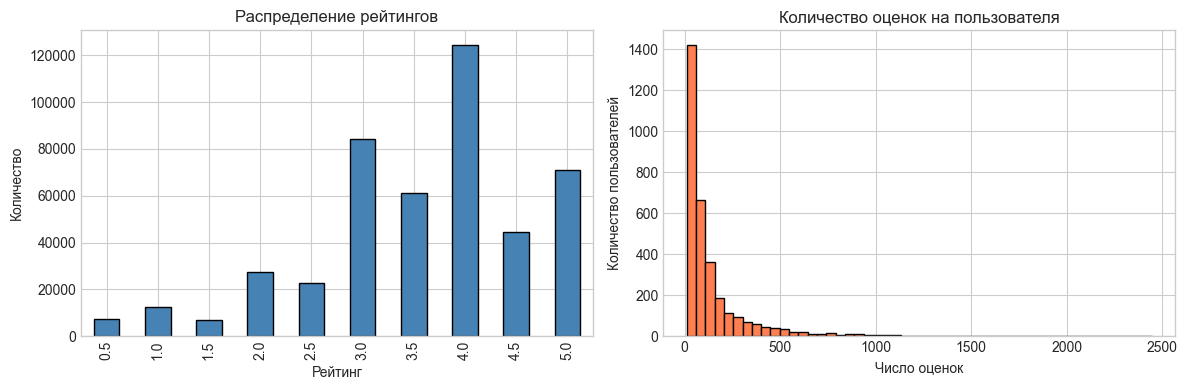

In [3]:
print("Фильтрация малоактивных пользователей и редких фильмов...")
print(f"До фильтрации: {len(ratings):,} записей")

for _ in range(3):
    user_counts = ratings["userId"].value_counts()
    movie_counts = ratings["movieId"].value_counts()

    active_users = user_counts[user_counts >= MIN_RATINGS_PER_USER].index
    active_movies = movie_counts[movie_counts >= MIN_RATINGS_PER_MOVIE].index

    ratings = ratings[
        ratings["userId"].isin(active_users)
        & ratings["movieId"].isin(active_movies)
    ].copy()

ratings.reset_index(drop=True, inplace=True)

print(f"После фильтрации: {len(ratings):,} записей")
print(f"Пользователей: {ratings['userId'].nunique():,}")
print(f"Фильмов: {ratings['movieId'].nunique():,}")

density = len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique())
print(f"Плотность полной матрицы: {density * 100:.4f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ratings["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("Распределение рейтингов")
axes[0].set_xlabel("Рейтинг")
axes[0].set_ylabel("Количество")

ratings.groupby("userId").size().hist(
    bins=50, ax=axes[1], color="coral", edgecolor="black"
)
axes[1].set_title("Количество оценок на пользователя")
axes[1].set_xlabel("Число оценок")
axes[1].set_ylabel("Количество пользователей")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "als_data_stats.png", dpi=120, bbox_inches="tight")
plt.show()


In [4]:
ratings = ratings.sort_values(["userId", "timestamp", "movieId"]).reset_index(drop=True)

user_sizes = ratings.groupby("userId")["movieId"].transform("size")
order_in_user = ratings.groupby("userId").cumcount()
n_test_per_user = np.floor(user_sizes * TEST_FRACTION).astype(int).clip(lower=1)
n_test_per_user = np.minimum(n_test_per_user, user_sizes - MIN_TRAIN_RATINGS_PER_USER)

test_mask = order_in_user >= (user_sizes - n_test_per_user)
train_data = ratings.loc[~test_mask].copy()
test_data = ratings.loc[test_mask].copy()

# Если после user-based split какой-то фильм не встретился в train,
# переносим одну тестовую оценку этого фильма обратно в обучение.
unseen_movies = sorted(set(test_data["movieId"]) - set(train_data["movieId"]))
if unseen_movies:
    rescued = (
        test_data[test_data["movieId"].isin(unseen_movies)]
        .sort_values(["movieId", "timestamp"])
        .groupby("movieId", group_keys=False)
        .head(1)
        .copy()
    )
    train_data = pd.concat([train_data, rescued], ignore_index=True)
    test_data = test_data.drop(index=rescued.index).copy()

train_data = train_data.sort_values(["userId", "timestamp", "movieId"]).reset_index(drop=True)
test_data = test_data.sort_values(["userId", "timestamp", "movieId"]).reset_index(drop=True)

train_users = set(train_data["userId"].unique())
train_movies = set(train_data["movieId"].unique())

print("Temporal split по каждому пользователю:")
print(f"  train: {len(train_data):,} записей")
print(f"  test:  {len(test_data):,} записей")
print(f"  пользователей в train: {len(train_users):,}")
print(f"  фильмов в train:       {len(train_movies):,}")
print(f"  unseen users в test:   {len(set(test_data['userId']) - train_users)}")
print(f"  unseen movies в test:  {len(set(test_data['movieId']) - train_movies)}")


Temporal split по каждому пользователю:
  train: 371,393 записей
  test:  91,267 записей
  пользователей в train: 3,238
  фильмов в train:       5,474
  unseen users в test:   0
  unseen movies в test:  0


In [5]:
unique_users = np.sort(train_data["userId"].unique())
unique_movies = np.sort(train_data["movieId"].unique())

user2idx = {uid: idx for idx, uid in enumerate(unique_users)}
idx2user = {idx: uid for uid, idx in user2idx.items()}
movie2idx = {mid: idx for idx, mid in enumerate(unique_movies)}
idx2movie = {idx: mid for mid, idx in movie2idx.items()}

movie_id_to_title = dict(zip(movies["movieId"], movies["title"].fillna("Unknown")))

train_data["user_idx"] = train_data["userId"].map(user2idx).astype("int32")
train_data["movie_idx"] = train_data["movieId"].map(movie2idx).astype("int32")
test_data["user_idx"] = test_data["userId"].map(user2idx).astype("int32")
test_data["movie_idx"] = test_data["movieId"].map(movie2idx).astype("int32")

n_users = len(unique_users)
n_movies = len(unique_movies)

R_train = sp.csr_matrix(
    (
        train_data["rating"].to_numpy(dtype=np.float32),
        (
            train_data["user_idx"].to_numpy(),
            train_data["movie_idx"].to_numpy(),
        ),
    ),
    shape=(n_users, n_movies),
    dtype=np.float32,
)
R_train_csc = R_train.tocsc()

print(f"Размер train-матрицы: {n_users} пользователей × {n_movies} фильмов")
print(f"Ненулевых элементов:   {R_train.nnz:,}")
print(f"Плотность train:       {R_train.nnz / (n_users * n_movies) * 100:.4f}%")
print("Разреженная матрица хранит только наблюдаемые оценки; пропуски нулями не заполняются.")


Размер train-матрицы: 3238 пользователей × 5474 фильмов
Ненулевых элементов:   371,393
Плотность train:       2.0953%
Разреженная матрица хранит только наблюдаемые оценки; пропуски нулями не заполняются.


## Реализация ALS

Ниже реализован `ALS` для sparse-матрицы:

- обновление факторов пользователей и фильмов делается по выведенным выше формулам;
- смещения (`bias`) обновляются отдельно как ridge-оценки;
- обучение и предсказания используют только наблюдаемые индексы `csr/csc`.


In [6]:
class ALSRecommender:
    def __init__(
        self,
        n_factors=24,
        n_iterations=25,
        lambda_reg=0.7,
        bias_reg=10.0,
        random_state=42,
    ):
        self.n_factors = n_factors
        self.n_iterations = n_iterations
        self.lambda_reg = lambda_reg
        self.bias_reg = bias_reg
        self.random_state = random_state

        self.U = None
        self.V = None
        self.user_bias = None
        self.item_bias = None
        self.global_mean = None
        self.rating_min = None
        self.rating_max = None
        self.rmse_history = []

    def _predict_raw(self, user_idx, movie_idx):
        user_idx = np.asarray(user_idx, dtype=np.int64)
        movie_idx = np.asarray(movie_idx, dtype=np.int64)
        interaction = np.sum(self.U[user_idx] * self.V[movie_idx], axis=1)
        return (
            self.global_mean
            + self.user_bias[user_idx]
            + self.item_bias[movie_idx]
            + interaction
        )

    def predict_batch(self, user_idx, movie_idx, clip=True):
        preds = self._predict_raw(user_idx, movie_idx).astype(np.float32)
        if clip:
            preds = np.clip(preds, self.rating_min, self.rating_max)
        return preds

    def predict_all_for_user(self, user_idx, clip=False):
        scores = (
            self.global_mean
            + self.user_bias[user_idx]
            + self.item_bias
            + self.V @ self.U[user_idx]
        ).astype(np.float32)
        if clip:
            scores = np.clip(scores, self.rating_min, self.rating_max)
        return scores

    def _compute_rmse(self, rows, cols, true_ratings, clip=False):
        preds = self.predict_batch(rows, cols, clip=clip)
        return float(np.sqrt(np.mean((true_ratings - preds) ** 2)))

    def fit(self, R_csr, verbose=True):
        rng = np.random.default_rng(self.random_state)
        m, n = R_csr.shape
        k = self.n_factors

        self.rating_min = float(R_csr.data.min())
        self.rating_max = float(R_csr.data.max())
        self.global_mean = float(R_csr.data.mean())

        self.U = rng.normal(0.0, 0.1, size=(m, k)).astype(np.float32)
        self.V = rng.normal(0.0, 0.1, size=(n, k)).astype(np.float32)
        self.user_bias = np.zeros(m, dtype=np.float32)
        self.item_bias = np.zeros(n, dtype=np.float32)
        self.rmse_history = []

        R_csc = R_csr.tocsc()
        rows, cols = R_csr.nonzero()
        true_ratings = R_csr.data.astype(np.float32)
        lambda_eye = self.lambda_reg * np.eye(k, dtype=np.float32)

        user_items = [
            R_csr.indices[R_csr.indptr[i] : R_csr.indptr[i + 1]]
            for i in range(m)
        ]
        user_ratings = [
            R_csr.data[R_csr.indptr[i] : R_csr.indptr[i + 1]].astype(np.float32)
            for i in range(m)
        ]
        item_users = [
            R_csc.indices[R_csc.indptr[j] : R_csc.indptr[j + 1]]
            for j in range(n)
        ]
        item_ratings = [
            R_csc.data[R_csc.indptr[j] : R_csc.indptr[j + 1]].astype(np.float32)
            for j in range(n)
        ]

        if verbose:
            print(
                f"ALS: users={m}, movies={n}, factors={k}, "
                f"iterations={self.n_iterations}, lambda={self.lambda_reg}"
            )

        total_start = time.time()

        for iteration in range(1, self.n_iterations + 1):
            iter_start = time.time()

            for i in range(m):
                rated_movie_ids = user_items[i]
                if len(rated_movie_ids) == 0:
                    continue

                r_i = user_ratings[i]
                V_i = self.V[rated_movie_ids]
                residual = (
                    r_i
                    - self.global_mean
                    - self.user_bias[i]
                    - self.item_bias[rated_movie_ids]
                )
                A = V_i.T @ V_i + lambda_eye
                b = V_i.T @ residual
                self.U[i] = np.linalg.solve(A, b)

            for j in range(n):
                rated_user_ids = item_users[j]
                if len(rated_user_ids) == 0:
                    continue

                r_j = item_ratings[j]
                U_j = self.U[rated_user_ids]
                residual = (
                    r_j
                    - self.global_mean
                    - self.user_bias[rated_user_ids]
                    - self.item_bias[j]
                )
                A = U_j.T @ U_j + lambda_eye
                b = U_j.T @ residual
                self.V[j] = np.linalg.solve(A, b)

            for i in range(m):
                rated_movie_ids = user_items[i]
                if len(rated_movie_ids) == 0:
                    continue

                r_i = user_ratings[i]
                interaction = np.sum(self.U[i] * self.V[rated_movie_ids], axis=1)
                residual = r_i - (
                    self.global_mean
                    + self.item_bias[rated_movie_ids]
                    + interaction
                )
                self.user_bias[i] = residual.sum() / (self.bias_reg + len(rated_movie_ids))

            for j in range(n):
                rated_user_ids = item_users[j]
                if len(rated_user_ids) == 0:
                    continue

                r_j = item_ratings[j]
                interaction = np.sum(self.U[rated_user_ids] * self.V[j], axis=1)
                residual = r_j - (
                    self.global_mean
                    + self.user_bias[rated_user_ids]
                    + interaction
                )
                self.item_bias[j] = residual.sum() / (self.bias_reg + len(rated_user_ids))

            train_rmse = self._compute_rmse(rows, cols, true_ratings, clip=False)
            self.rmse_history.append(train_rmse)

            if verbose:
                print(
                    f"Итерация {iteration:2d}/{self.n_iterations} | "
                    f"train RMSE={train_rmse:.4f} | "
                    f"time={time.time() - iter_start:.2f}s"
                )

        if verbose:
            print(f"Обучение завершено за {time.time() - total_start:.2f} с")

        return self

    def recommend(
        self,
        user_id,
        top_k,
        user2idx,
        idx2movie,
        R_csr,
        movie_id_to_title,
    ):
        if user_id not in user2idx:
            return []

        user_idx = user2idx[user_id]
        raw_scores = self.predict_all_for_user(user_idx, clip=False)
        shown_scores = np.clip(raw_scores.copy(), self.rating_min, self.rating_max)

        seen_movie_idx = R_csr.getrow(user_idx).indices
        raw_scores = raw_scores.copy()
        raw_scores[seen_movie_idx] = -np.inf

        top_k = min(top_k, len(raw_scores))
        candidate_idx = np.argpartition(raw_scores, -top_k)[-top_k:]
        top_movie_indices = candidate_idx[np.argsort(raw_scores[candidate_idx])[::-1]]

        recommendations = []
        for movie_idx in top_movie_indices:
            movie_id = idx2movie[movie_idx]
            recommendations.append(
                {
                    "movie_id": int(movie_id),
                    "title": str(movie_id_to_title.get(movie_id, f"Unknown (id={movie_id})")),
                    "raw_score": float(raw_scores[movie_idx]),
                    "predicted_rating": float(shown_scores[movie_idx]),
                }
            )
        return recommendations


In [7]:
model = ALSRecommender(
    n_factors=24,
    n_iterations=25,
    lambda_reg=0.7,
    bias_reg=10.0,
    random_state=RANDOM_STATE,
)

model.fit(R_train, verbose=True)


ALS: users=3238, movies=5474, factors=24, iterations=25, lambda=0.7


Итерация  1/25 | train RMSE=0.6800 | time=0.18s


Итерация  2/25 | train RMSE=0.5749 | time=0.17s


Итерация  3/25 | train RMSE=0.5385 | time=0.17s


Итерация  4/25 | train RMSE=0.5193 | time=0.17s


...

Итерация 21/25 | train RMSE=0.4669 | time=0.18s


Итерация 22/25 | train RMSE=0.4662 | time=0.18s


Итерация 23/25 | train RMSE=0.4656 | time=0.18s


Итерация 24/25 | train RMSE=0.4651 | time=0.19s


Итерация 25/25 | train RMSE=0.4646 | time=0.23s
Обучение завершено за 4.42 с


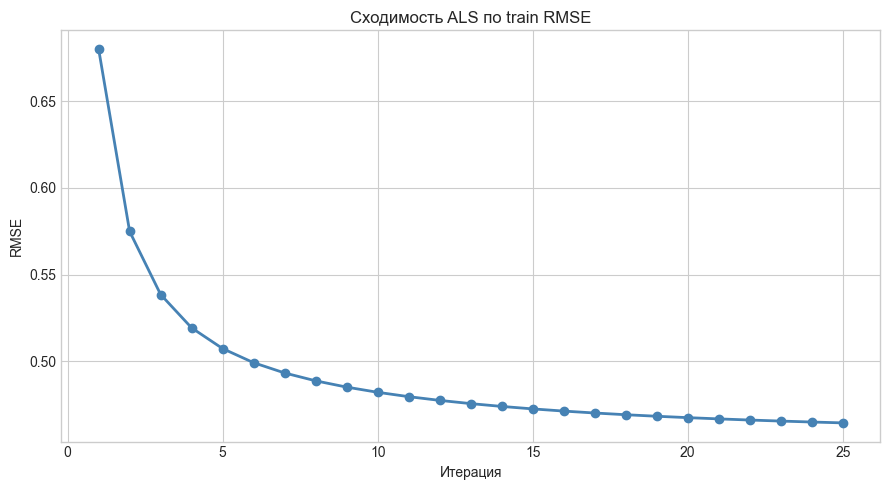

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    np.arange(1, len(model.rmse_history) + 1),
    model.rmse_history,
    marker="o",
    color="steelblue",
    linewidth=2,
)
ax.set_title("Сходимость ALS по train RMSE")
ax.set_xlabel("Итерация")
ax.set_ylabel("RMSE")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "als_rmse_curve.png", dpi=120, bbox_inches="tight")
plt.show()


In [9]:
test_user_idx = test_data["user_idx"].to_numpy(dtype=np.int32)
test_movie_idx = test_data["movie_idx"].to_numpy(dtype=np.int32)
true_test_ratings = test_data["rating"].to_numpy(dtype=np.float32)

pred_test_ratings = model.predict_batch(test_user_idx, test_movie_idx, clip=True)
test_rmse = float(np.sqrt(np.mean((true_test_ratings - pred_test_ratings) ** 2)))
test_mae = float(np.mean(np.abs(true_test_ratings - pred_test_ratings)))

print("Метрики rating prediction на test:")
print(f"  RMSE = {test_rmse:.4f}")
print(f"  MAE  = {test_mae:.4f}")


Метрики rating prediction на test:
  RMSE = 1.0122
  MAE  = 0.7520


In [10]:
TOP_K = 10
sample_users = (
    train_data.groupby("userId")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

example_recommendations = {}
for user_id in sample_users:
    recs = model.recommend(
        user_id=user_id,
        top_k=TOP_K,
        user2idx=user2idx,
        idx2movie=idx2movie,
        R_csr=R_train,
        movie_id_to_title=movie_id_to_title,
    )
    example_recommendations[user_id] = recs

    user_idx = user2idx[user_id]
    seen_cnt = R_train.getrow(user_idx).nnz
    print(f"\n=== Пользователь #{user_id} | train-оценок: {seen_cnt} ===")
    for rank, rec in enumerate(recs, start=1):
        print(
            f"{rank:2d}. {rec['title'][:70]:<70} | "
            f"raw={rec['raw_score']:.3f} | clipped={rec['predicted_rating']:.3f}"
        )



=== Пользователь #28 | train-оценок: 1958 ===
 1. Planet Earth (2006)                                                    | raw=5.658 | clipped=5.000
 2. Dr. Horrible's Sing-Along Blog (2008)                                  | raw=5.576 | clipped=5.000
 3. Mr. Nobody (2009)                                                      | raw=5.531 | clipped=5.000
 4. His Girl Friday (1940)                                                 | raw=5.462 | clipped=5.000
 5. Manchester by the Sea (2016)                                           | raw=5.442 | clipped=5.000
 6. Cabaret (1972)                                                         | raw=5.425 | clipped=5.000
 7. Hunt for the Wilderpeople (2016)                                       | raw=5.381 | clipped=5.000
 8. Persona (1966)                                                         | raw=5.359 | clipped=5.000
 9. Hate (Haine, La) (1995)                                                | raw=5.351 | clipped=5.000
10. Lives of Others, The (

In [11]:
RELEVANCE_THRESHOLD = 4.0
K_VALUES = [5, 10, 20]


def evaluate_topk(model, test_df, R_train, k_values, threshold=4.0):
    results = {k: {"precision": [], "recall": []} for k in k_values}
    grouped = test_df.groupby("user_idx")

    for user_idx, user_test in grouped:
        relevant_movies = set(
            user_test.loc[user_test["rating"] >= threshold, "movie_idx"].astype(int).tolist()
        )
        if not relevant_movies:
            continue

        scores = model.predict_all_for_user(int(user_idx), clip=False)
        scores = scores.copy()
        seen = R_train.getrow(int(user_idx)).indices
        scores[seen] = -np.inf

        ranking = np.argsort(scores)[::-1]
        for k in k_values:
            top_k = set(ranking[:k].tolist())
            hits = len(top_k & relevant_movies)
            results[k]["precision"].append(hits / k)
            results[k]["recall"].append(hits / len(relevant_movies))

    summary = {}
    for k in k_values:
        summary[k] = {
            "precision_at_k": float(np.mean(results[k]["precision"])) if results[k]["precision"] else 0.0,
            "recall_at_k": float(np.mean(results[k]["recall"])) if results[k]["recall"] else 0.0,
            "n_users": len(results[k]["precision"]),
        }
    return summary


pr_results = evaluate_topk(
    model=model,
    test_df=test_data,
    R_train=R_train,
    k_values=K_VALUES,
    threshold=RELEVANCE_THRESHOLD,
)

print(f"Порог релевантности: rating >= {RELEVANCE_THRESHOLD}")
for k in K_VALUES:
    row = pr_results[k]
    print(
        f"K={k:2d} | precision@k={row['precision_at_k']:.4f} | "
        f"recall@k={row['recall_at_k']:.4f} | users={row['n_users']}"
    )


Порог релевантности: rating >= 4.0
K= 5 | precision@k=0.0100 | recall@k=0.0029 | users=3171
K=10 | precision@k=0.0098 | recall@k=0.0060 | users=3171
K=20 | precision@k=0.0102 | recall@k=0.0130 | users=3171


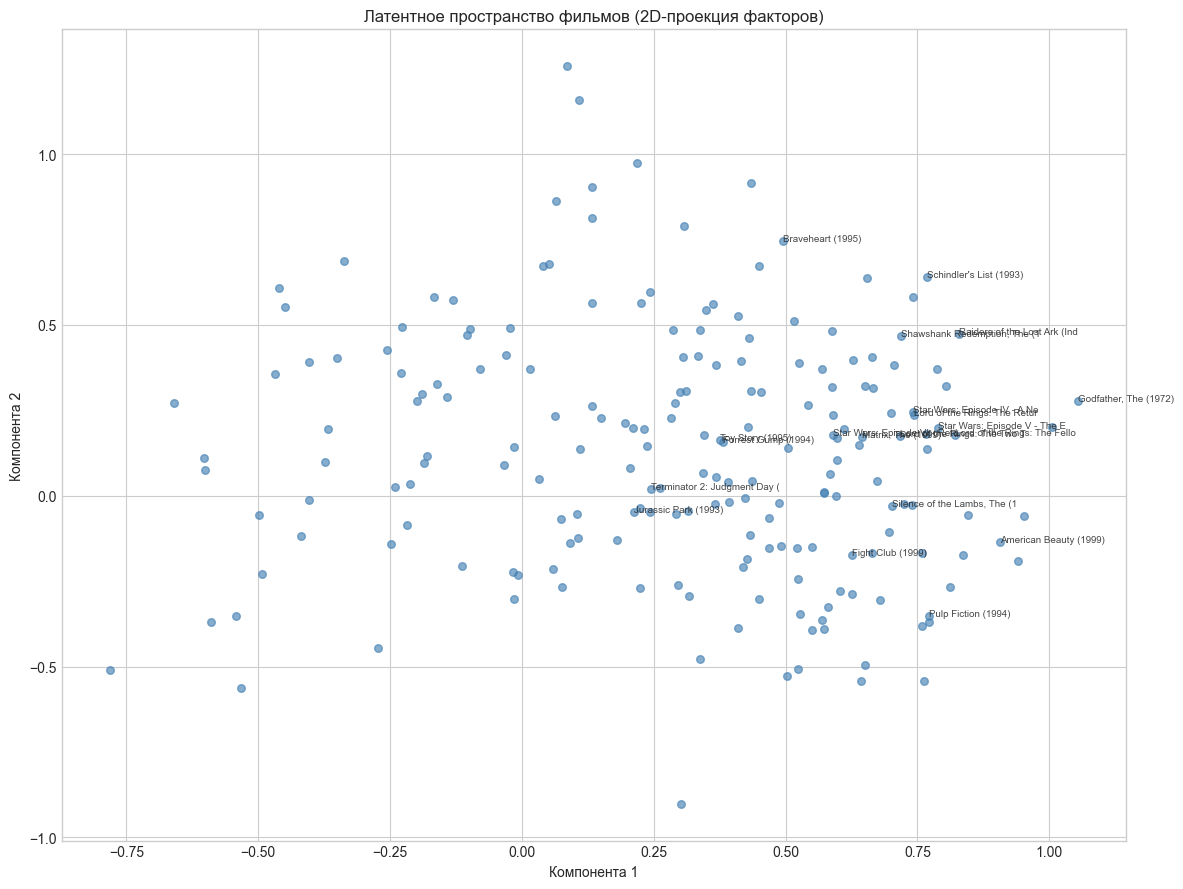

In [12]:
from numpy.linalg import svd

V_centered = model.V - model.V.mean(axis=0, keepdims=True)
_, _, vt = svd(V_centered, full_matrices=False)
V_2d = V_centered @ vt[:2].T

top_movies = (
    train_data.groupby("movie_idx")
    .size()
    .sort_values(ascending=False)
    .head(200)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(V_2d[top_movies, 0], V_2d[top_movies, 1], s=30, alpha=0.65, color="steelblue")

for idx in top_movies[:20]:
    movie_id = idx2movie[idx]
    title = str(movie_id_to_title.get(movie_id, "Unknown"))[:28]
    ax.annotate(title, (V_2d[idx, 0], V_2d[idx, 1]), fontsize=7, alpha=0.85)

ax.set_title("Латентное пространство фильмов (2D-проекция факторов)")
ax.set_xlabel("Компонента 1")
ax.set_ylabel("Компонента 2")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "als_latent_space.png", dpi=120, bbox_inches="tight")
plt.show()


## Проверка критериев приемки

Ниже проверяем три требования задания:

1. **Математически верный вывод формул** — приведен в секции *Математический вывод ALS*.
2. **Работающая функция рекомендаций Top-K** — проверяется автоматически на длину списка и на отсутствие уже просмотренных фильмов.
3. **Эффективная работа с пропусками без заполнения нулями** — проверяется через `scipy.sparse`, число ненулевых элементов и отсутствие unseen-объектов в test после split.


In [13]:
first_user_id = sample_users[0]
first_user_idx = user2idx[first_user_id]
first_seen_movies = set(R_train.getrow(first_user_idx).indices.tolist())
first_recommended_movies = {
    movie2idx[rec["movie_id"]]
    for rec in example_recommendations[first_user_id]
}

unseen_users_in_test = set(test_data["userId"]) - set(train_data["userId"])
unseen_movies_in_test = set(test_data["movieId"]) - set(train_data["movieId"])

acceptance_checks = {
    "top_k_exact_length": len(example_recommendations[first_user_id]) == TOP_K,
    "top_k_excludes_seen_items": len(first_seen_movies & first_recommended_movies) == 0,
    "train_matrix_is_sparse": sp.isspmatrix_csr(R_train),
    "nnz_equals_number_of_train_ratings": R_train.nnz == len(train_data),
    "test_has_only_seen_users": len(unseen_users_in_test) == 0,
    "test_has_only_seen_movies": len(unseen_movies_in_test) == 0,
}

for check_name, passed in acceptance_checks.items():
    print(f"{check_name:35s}: {'OK' if passed else 'FAIL'}")

assert all(acceptance_checks.values()), "Не все критерии автоматически выполнены."

print("\nИтог:")
print("- формулы обновления приведены в markdown-ячейке выше;")
print("- Top-K рекомендации формируются корректно и без уже просмотренных фильмов;")
print("- пропуски обрабатываются через sparse-матрицу, без заполнения нулями.")


top_k_exact_length                 : OK
top_k_excludes_seen_items          : OK
train_matrix_is_sparse             : OK
nnz_equals_number_of_train_ratings : OK
test_has_only_seen_users           : OK
test_has_only_seen_movies          : OK

Итог:
- формулы обновления приведены в markdown-ячейке выше;
- Top-K рекомендации формируются корректно и без уже просмотренных фильмов;
- пропуски обрабатываются через sparse-матрицу, без заполнения нулями.


In [14]:
summary_rows = []
for k in K_VALUES:
    summary_rows.append(
        {
            "K": k,
            "precision_at_k": pr_results[k]["precision_at_k"],
            "recall_at_k": pr_results[k]["recall_at_k"],
            "users": pr_results[k]["n_users"],
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df


,K,precision_at_k,recall_at_k,users
0,5,0.010028,0.002946,3171
1,10,0.009808,0.006027,3171
2,20,0.010170,0.013013,3171
